In [3]:
import torch
import torch.nn as nn
import numpy as np
import sys
import os
import json
import itertools
import pandas as pd
import gc  # Added for memory cleanup
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Referencing your project structure verbatim
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP # Verbatim reference to architectures.py
from src.utils import set_seed, apply_heavy_tailed_init # Verbatim reference to utils.py

def save_physics_snapshot(model, input_batch, output_dir, t_idx, epoch, alpha, g):
    model.eval()

    # Capture physics data as before
    pre_acts = model.get_pre_activations(input_batch)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    layer_physics = {}
    for idx, layer in enumerate(linear_layers):
        layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
        h = pre_acts[idx] if idx < len(linear_layers) - 1 else pre_acts["classifier"]

        # Compute Jacobian using float32 for precision
        W = layer.weight.data.float()
        d_act = 1.0 - torch.tanh(h).pow(2).float()
        D_avg = d_act.mean(dim=0)
        J = D_avg.unsqueeze(1) * W

        layer_physics[layer_key] = {
            "pre_activations": h.float().cpu(),
            "jacobian": J.cpu()
        }

    snapshot = {
        "metadata": {"task": t_idx + 1, "epoch": epoch, "alpha": alpha, "g": g},
        "state_dict": model.state_dict(), # Native PyTorch format
        "physics": layer_physics         # Your specific research metrics
    }

    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"snapshot_T{t_idx+1}_E{epoch}.pt"
    torch.save(snapshot, file_path)
    return file_path

def update_GPM_bases(model, images, threshold, feature_list=None):
    model.eval()
    with torch.no_grad():
        reps = model.get_pre_activations(images)

    all_inputs = [images]
    for h in list(reps.values())[:-1]:
        all_inputs.append(torch.tanh(h))

    if feature_list is None:
        feature_list = [None] * len(all_inputs)

    current_ranks = []
    for i, activation in enumerate(all_inputs):
        X = activation.cpu().numpy()
        U, S, Vh = np.linalg.svd(X, full_matrices=False)

        s_sq = S**2
        s_sum = np.sum(s_sq)

        # Vectorized threshold calculation (cleaner than the manual loop)
        cumulative_variance = np.cumsum(s_sq) / s_sum
        k = np.argmax(cumulative_variance >= threshold) + 1
        current_ranks.append(k) # Store k for logging

        task_basis = Vh[:k].T

        if feature_list[i] is None:
            feature_list[i] = task_basis
        else:
            # We must bring the existing GPU tensor back to CPU numpy for the SVD merge
            old_basis = feature_list[i].cpu().numpy()
            combined = np.concatenate((old_basis, task_basis), axis=1)
            U_new, _, _ = np.linalg.svd(combined, full_matrices=False)
            feature_list[i] = U_new[:, :min(combined.shape[0], combined.shape[1])]

    # CRITICAL: Pre-load the bases to the GPU here, NOT in the training loop
    device = next(model.parameters()).device
    tensor_bases = [
        torch.tensor(b, dtype=torch.float32, device=device) if b is not None else None
        for b in feature_list
    ]

    return tensor_bases, current_ranks


def apply_GPM_projection(linear_layers, feature_list):
    """
    Args:
        linear_layers: A pre-cached list of nn.Linear modules.
        feature_list: The pre-loaded GPU tensors from update_GPM_bases.
    """
    if feature_list is None:
        return

    with torch.no_grad():
        for i, layer in enumerate(linear_layers):
            if i >= len(feature_list) or feature_list[i] is None:
                continue

            grad = layer.weight.grad
            if grad is None:
                continue

            basis = feature_list[i] # Already a GPU tensor!

            # Math: g_proj = g - (g @ B @ B.T)
            proj_grad = grad - torch.mm(torch.mm(grad, basis), basis.t())
            layer.weight.grad.copy_(proj_grad)

In [ ]:
# --- 1. CONFIGURATION ---
num_tasks = 5  # Standard for Split Fashion-MNIST (2 classes per task)
seeds = [42]  # Multiple seeds for robustness
alpha_list = [2.0, 1.8, 1.6, 1.4, 1.2, 1.0]
g_list = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
depth = 9
hidden_size = 784
bias = False
activation_name = "tanh"
optimiser = "sgd"
batch_size = 128
lr = 1e-3
epochs = 30
snapshot_epochs = [0, 14, 29]
GPM_THRESHOLD = 0.97

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. DATA LOADING & SPLITTING ---
def get_split_tasks(dataset, num_tasks=5):
    """Filters dataset into subsets of 2 classes per task."""
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)

    task_bundles = []
    # Create 5 tasks: (0,1), (2,3), (4,5), (6,7), (8,9)
    for i in range(num_tasks):
        c1, c2 = 2*i, 2*i + 1
        mask = (lbls == c1) | (lbls == c2)
        task_bundles.append((imgs[mask], lbls[mask]))
    return task_bundles

print("Fast-loading Fashion-MNIST to GPU and splitting by class...")
f_train = datasets.FashionMNIST('../data', train=True, download=True, transform=transforms.ToTensor())
f_test = datasets.FashionMNIST('../data', train=False, download=True, transform=transforms.ToTensor())

# Pre-split the data into 5 tasks
train_tasks = get_split_tasks(f_train, num_tasks)
test_tasks = get_split_tasks(f_test, num_tasks)

# --- 3. GRID SWEEP EXECUTION ---
for seed in seeds:
    print(f"\n=== Starting experiments for seed {seed} ===")
    for alpha, g in itertools.product(alpha_list, g_list):
        set_seed(seed) # Assuming your set_seed function is defined globally
        run_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
        output_dir = Path(f"./sweep_fashion_gpm{GPM_THRESHOLD}_fc{depth+1}/{run_name}")
        output_dir.mkdir(parents=True, exist_ok=True)

        # Metadata Logging
        config_params = {
            "alpha": alpha, "g": g, "seed": seed, "depth": depth,
            "hidden_size": hidden_size, "lr": lr, "batch_size": batch_size,
            "activation": activation_name, "num_tasks": num_tasks,
            "snapshot_epochs": snapshot_epochs, "bias": bias,
            "scenario": "Split Fashion-MNIST"
        }
        with open(output_dir / f"run_config_seed_{seed}.json", "w") as f:
            json.dump(config_params, f, indent=4)

        # Note: Ensure GeneralMLP and apply_heavy_tailed_init are available in your scope
        model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(device)
        apply_heavy_tailed_init(model, alpha=alpha, g=g, base_seed=seed)

        # 1. CACHE THE LAYERS ONCE
        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        criterion = torch.nn.CrossEntropyLoss()
        results_history = []
        gpm_feature_bases = None

        for t_idx in range(num_tasks):
            print(f"\n[{run_name}] --- Task {t_idx + 1} ---")
            curr_train_imgs, curr_train_lbls = train_tasks[t_idx]
            train_loader = DataLoader(TensorDataset(curr_train_imgs, curr_train_lbls),
                                    batch_size=batch_size, shuffle=True)

            for epoch in range(epochs):
                model.train()
                total_train_loss, train_correct, train_total = 0, 0, 0
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()

                    # --- NEW: GPM PROJECTION STEP ---
                    if t_idx > 0:
                        apply_GPM_projection(linear_layers, gpm_feature_bases)

                    optimizer.step()

                    total_train_loss += loss.item()
                    train_correct += (outputs.argmax(1) == labels).sum().item()
                    train_total += labels.size(0)

                # Snapshot saving (Capturing first batch of current task)
                # if epoch in snapshot_epochs:
                #     save_physics_snapshot(model, curr_train_imgs[:batch_size],
                #                         output_dir / "checkpoints", t_idx, epoch, alpha, g)

                # Evaluation phase: Check current and all previous tasks
                model.eval()
                epoch_metrics = {
                    "alpha": alpha, "g": g, "epoch": epoch + 1, "task_id": t_idx + 1,
                    "train_loss": total_train_loss / len(train_loader),
                    "train_acc": train_correct / train_total,
                }

                # Pre-fill columns for all possible 5 tasks
                for i in range(num_tasks):
                    epoch_metrics[f"task_{i+1}_acc"] = np.nan

                with torch.no_grad():
                    for prev_t_idx in range(t_idx + 1):
                        val_imgs, val_lbls = test_tasks[prev_t_idx]
                        outputs = model(val_imgs)
                        acc = (outputs.argmax(1) == val_lbls).float().mean().item()
                        epoch_metrics[f"task_{prev_t_idx+1}_acc"] = acc

                results_history.append(epoch_metrics)

                # Live tracking printout
                # print(f"Ep {epoch+1:02d} | T1: {epoch_metrics['task_1_acc']:.4f} | "
                #     f"Curr: {epoch_metrics[f'task_{t_idx+1}_acc']:.4f} | Loss: {epoch_metrics['train_loss']:.4f}")

            # --- AFTER TASK COMPLETION: UPDATE GPM MEMORY ---
            print(f"Updating GPM memory for Task {t_idx+1}...")
            # Use a small subset (e.g., 300 samples) of the current task for SVD
            svd_samples = curr_train_imgs[:300]
            gpm_feature_bases, task_ranks = update_GPM_bases(model, svd_samples, GPM_THRESHOLD, gpm_feature_bases)

            if results_history:
                for i, r in enumerate(task_ranks):
                    results_history[-1][f"layer_{i}_rank"] = r

                # Also log a "Total Capacity" metric (sum of ranks across layers)
                results_history[-1]["total_rank_sum"] = sum(task_ranks)

            # Printout for immediate feedback
            # for i, r in enumerate(task_ranks):
            #     print(f"  Layer {i} Rank: {r}")

        # Save and Cleanup
        df = pd.DataFrame(results_history)
        df.to_csv(output_dir / f"results_log_seed_{seed}.csv", index=False)

        del model, optimizer, results_history, df
        torch.cuda.empty_cache()
        gc.collect()

Processed 20 seeds for α=2.0, g=3.0
Processed 20 seeds for α=1.2, g=1.0


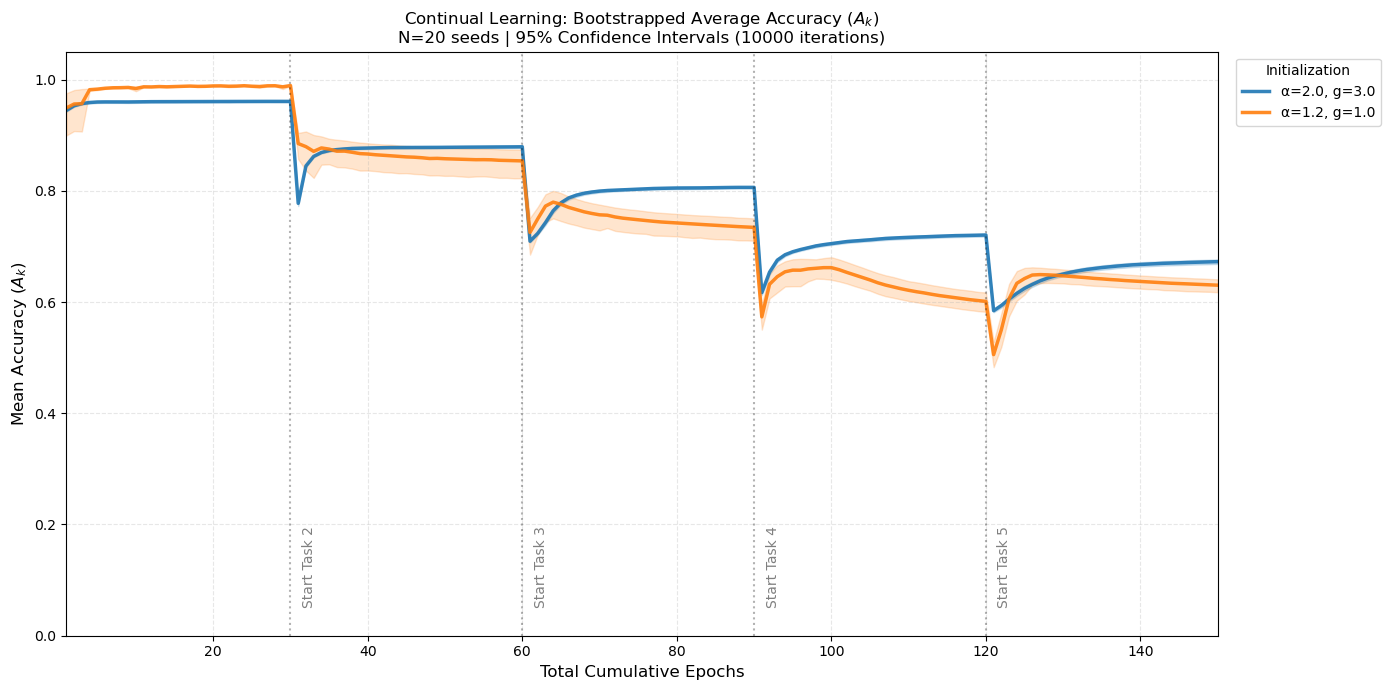

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fashion_gpm0.97_fc10")
num_tasks = 5

def plot_multiple_accuracies_bootstrapped(param_pairs, n_boot=1000):
    """
    Plots the Mean Average Accuracy (Ak) with bootstrapped 95% Confidence Intervals.
    param_pairs: List of tuples [(alpha, g, lr), ...]
    n_boot: Number of bootstrap iterations (1000 is standard for research)
    """
    master_plot_data = []
    task_transition_epochs = None

    for alpha, g, lr in param_pairs:
        folder_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
        folder_path = results_path / folder_name
        condition_label = f"α={alpha}, g={g}"

        if not folder_path.exists():
            print(f"Skipping: {folder_path} (not found).")
            continue

        seed_count = 0
        # Iterate through all seed files found in the directory
        for csv_file in folder_path.glob("results_log_seed_*.csv"):
            df = pd.read_csv(csv_file)

            seed_count += 1

            # 2. Process Epochs for Ak calculation
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])
                task_cols = [f"task_{i}_acc" for i in range(1, current_task_id + 1)]
                mean_acc = row[task_cols].mean()

                master_plot_data.append({
                    "Total Epoch": idx + 1,
                    "Average Accuracy": mean_acc,
                    "Condition": condition_label,
                    "Seed": seed_count  # Essential for the bootstrap unit
                })

            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} seeds for {condition_label}")

    if not master_plot_data:
        print("No data found to plot.")
        return

    plot_df = pd.DataFrame(master_plot_data)

    # --- Plotting ---
    plt.figure(figsize=(14, 7))

    # Seaborn 0.12+ Syntax: errorbar=('ci', 95) enables bootstrapping
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Average Accuracy",
        hue="Condition",
        errorbar=("ci", 95), # 95% Confidence Interval via Bootstrapping
        n_boot=n_boot,       # Number of resamples
        linewidth=2.5,
        alpha=0.9
    )

    # Vertical markers for Task transitions
    if task_transition_epochs:
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
            plt.text(epoch_mark + 1.5, 0.05, f"Start Task {t_idx+2}",
                     fontsize=10, rotation=90, verticalalignment='bottom', alpha=0.5)

    plt.title(f"Continual Learning: Bootstrapped Average Accuracy ($A_k$)\n"
              f"N={seed_count} seeds | 95% Confidence Intervals ({n_boot} iterations)")
    plt.ylim(0, 1.05)
    plt.xlim(1, plot_df["Total Epoch"].max())
    plt.ylabel("Mean Accuracy ($A_k$)", fontsize=12)
    plt.xlabel("Total Cumulative Epochs", fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Initialization")
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Once you have your 20 seeds in the background, this will produce very smooth CIs.
comparison_list = [
    (2.0, 3.0, 0.001),
    (1.2, 1.0, 0.001),
    #(1.2, 3.0, 0.001),
]

plot_multiple_accuracies_bootstrapped(comparison_list, n_boot=10000)

Processed 20 seeds for α=2.0, g=3.0


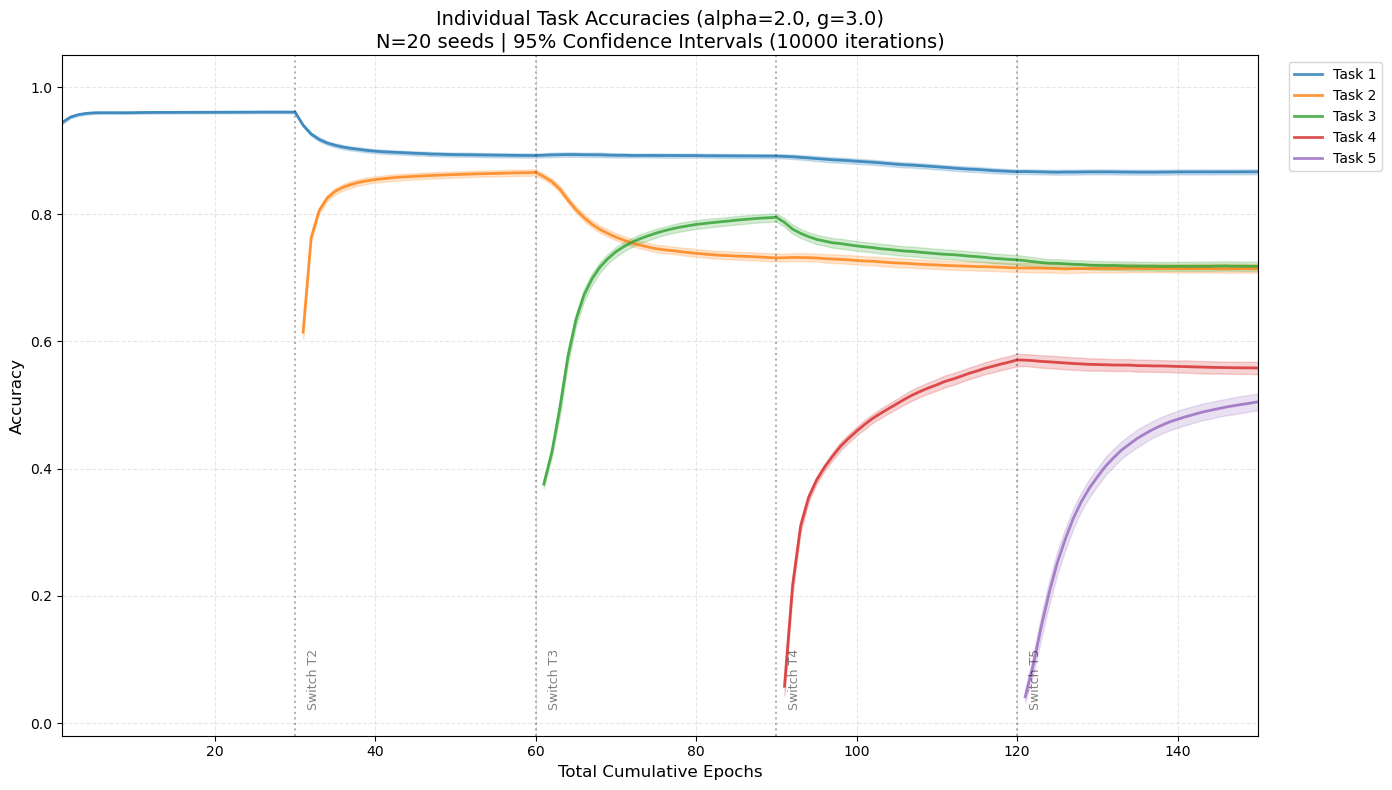

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fashion_gpm0.97_fc10")
task_success_threshold = 0.50  # Ensure the model actually learned Task 1
num_tasks = 5

def plot_individual_tasks_with_seeds(param_pairs, n_boot=1000):
    """
    Plots individual task accuracy lines aggregated over multiple seeds.
    param_pairs: List of tuples [(alpha, g, lr), ...]
    """
    master_plot_data = []
    task_transition_epochs = None

    for alpha, g, lr in param_pairs:
        folder_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
        folder_path = results_path / folder_name
        condition_label = f"α={alpha}, g={g}"

        if not folder_path.exists():
            print(f"Skipping: {folder_path} (not found).")
            continue

        seed_count = 0
        # Same Seed Logic: Glob all seeds in the condition folder
        for csv_file in folder_path.glob("results_log_seed_*.csv"):
            df = pd.read_csv(csv_file)

            # Trainability Filter: Skip seeds where Task 1 didn't converge
            if df[df['task_id'] == 1]['task_1_acc'].max() < task_success_threshold:
                continue

            seed_count += 1

            # Individual Curve Extraction
            # We melt the task_n_acc columns while preserving the epoch and seed
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])

                # Collect accuracy for every task introduced so far
                for t in range(1, num_tasks + 1):
                    col = f"task_{t}_acc"
                    if col in row and not pd.isna(row[col]):
                        master_plot_data.append({
                            "Total Epoch": idx + 1,
                            "Accuracy": row[col],
                            "Task": f"Task {t}",
                            "Condition": condition_label,
                            "Seed": seed_count
                        })

            # Capture transition points from the first valid seed
            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} seeds for {condition_label}")

    if not master_plot_data:
        print("No data found.")
        return

    plot_df = pd.DataFrame(master_plot_data)

    # --- Plotting ---
    plt.figure(figsize=(14, 8))

    # Use 'hue' for Tasks and 'style' for different α/g conditions
    # This prevents the lines from overlapping confusingly
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Accuracy",
        hue="Task",
        style="Condition" if len(param_pairs) > 1 else None,
        errorbar=("ci", 95),  # The shaded region showing variance across seeds
        n_boot=n_boot,       # Number of bootstrap iterations for CI
        palette="tab10",
        linewidth=2,
        alpha=0.8
    )

    # Transition markers
    if task_transition_epochs:
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            plt.axvline(x=epoch_mark, color='black', linestyle=':', alpha=0.3)
            plt.text(epoch_mark + 1.5, 0.02, f"Switch T{t_idx+2}",
                     fontsize=9, rotation=90, alpha=0.5, verticalalignment='bottom')

    plt.title(f"Individual Task Accuracies (alpha={param_pairs[0][0]}, g={param_pairs[0][1]})\n"
              f"N={seed_count} seeds | 95% Confidence Intervals ({n_boot} iterations)", fontsize=14)
    plt.ylabel("Accuracy", fontsize=12)
    plt.xlabel("Total Cumulative Epochs", fontsize=12)
    plt.ylim(-0.02, 1.05)
    plt.xlim(1, plot_df["Total Epoch"].max())
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# --- Execution ---
# Running for one condition at a time is clearest for individual curves
comparison_list = [
    #(1.2, 1.0, 0.001),
    (2.0, 3.0, 0.001)
]

plot_individual_tasks_with_seeds(comparison_list, n_boot=10000)

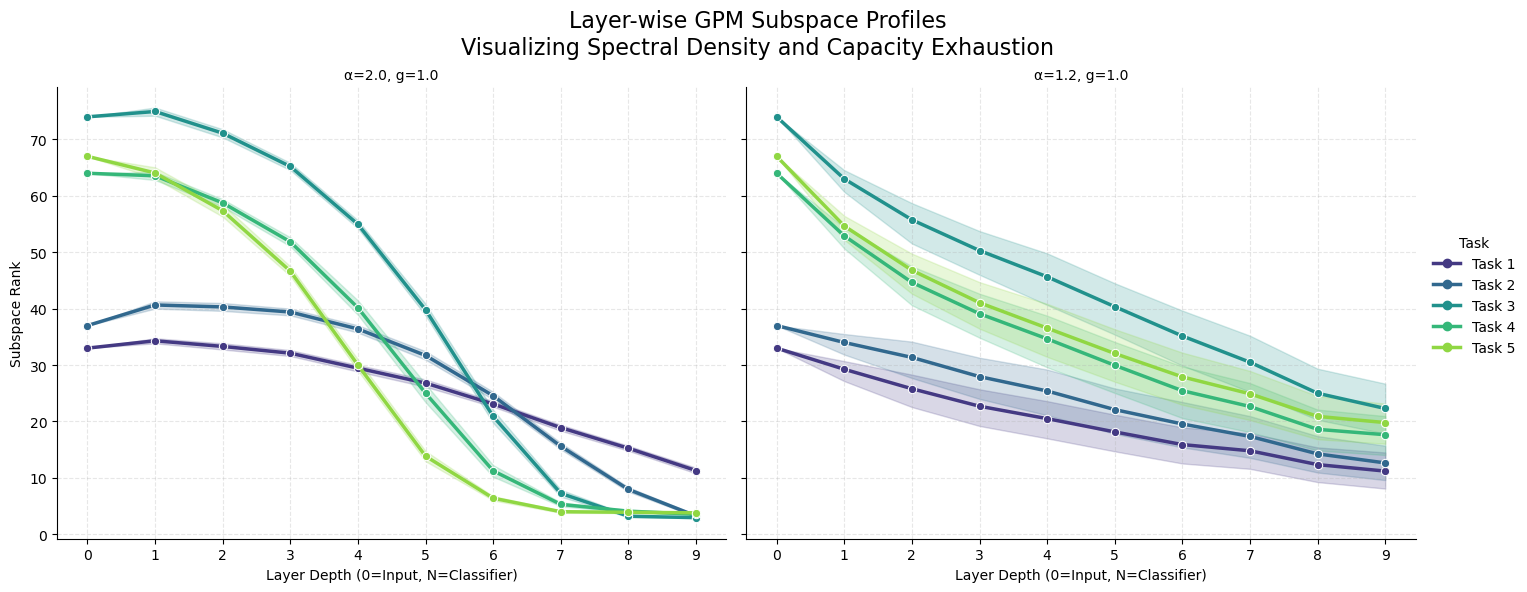

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path

# --- Configuration ---
results_path = Path("./results_fashion_gpm0.97_fc10")
num_tasks = 5

def plot_layer_rank_profiles(param_pairs, n_boot=1000):
    """
    Plots the rank of each layer (y-axis) against layer depth (x-axis).
    Shows how memory is distributed throughout the network architecture.
    """
    profile_data = []

    for alpha, g, lr in param_pairs:
        folder_name = f"split_fashion_alpha_{alpha}_g_{g}_lr_{lr}"
        folder_path = results_path / folder_name
        condition_label = f"α={alpha}, g={g}"

        if not folder_path.exists():
            print(f"Skipping: {folder_path} (not found).")
            continue

        for csv_file in folder_path.glob("results_log_seed_*.csv"):
            seed_val = re.search(r"seed_(\d+)", csv_file.name).group(1)
            df = pd.read_csv(csv_file)

            # 1. Identify Snapshot Rows
            # Ranks are logged at the end of each task. We take the last row of each task_id.
            snapshots = df.groupby('task_id').tail(1)

            for _, row in snapshots.iterrows():
                task_id = int(row['task_id'])

                # 2. Extract Layer Ranks
                # Find all columns named layer_X_rank
                rank_cols = [c for c in df.columns if c.startswith('layer_') and c.endswith('_rank')]

                for col in rank_cols:
                    # Extract the layer index from the column name
                    layer_idx = int(re.search(r"layer_(\d+)_rank", col).group(1))

                    profile_data.append({
                        "Layer Depth": layer_idx,
                        "Rank": row[col],
                        "Task": f"Task {task_id}",
                        "Condition": condition_label,
                        "Seed": seed_val
                    })

    if not profile_data:
        print("No rank data found in CSVs.")
        return

    plot_df = pd.DataFrame(profile_data)

    # --- Plotting ---
    # We use relplot to create facets if comparing multiple alpha/g conditions
    g = sns.relplot(
        data=plot_df,
        x="Layer Depth",
        y="Rank",
        hue="Task",
        col="Condition",
        kind="line",
        marker="o",
        errorbar=("ci", 95),  # Show 95% CI across seeds
        n_boot=n_boot,       # Number of bootstrap iterations for CI
        linewidth=2.5,
        palette="viridis",
        height=6,
        aspect=1.2
    )

    # Formatting
    g.set_axis_labels("Layer Depth (0=Input, N=Classifier)", "Subspace Rank")
    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.grid(True, which='both', linestyle='--', alpha=0.3)
        ax.set_xticks(range(int(plot_df["Layer Depth"].max()) + 1))
        # Optional: Add a line for the maximum possible rank (hidden_size)
        # ax.axhline(y=784, color='red', linestyle=':', alpha=0.4, label="Saturation (784)")

    plt.subplots_adjust(top=0.85)
    g.fig.suptitle("Layer-wise GPM Subspace Profiles\n"
                   "Visualizing Spectral Density and Capacity Exhaustion", fontsize=16)

    plt.show()

# --- Execution ---
comparison_list = [
    (2.0, 1.0, 0.001),
    (1.2, 1.0, 0.001)
]

plot_layer_rank_profiles(comparison_list, n_boot=10000)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import sys
import os
import pandas as pd
from pathlib import Path

# --- 1. CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROBE_EPOCHS = 30
BATCH_SIZE = 1024
# Updated Path: Targeting the final task of the Split Fashion experiment
SNAPSHOT_PATH = Path("./results_fashion_fc10/split_fashion_alpha_1.2_g_1.0_lr_0.001/checkpoints/snapshot_T5_E29.pt")
OUTPUT_CSV = Path("../results/continual_learning") / "fashion_layerwise_probe_results.csv"

# Architecture params
DEPTH = 9
HIDDEN_SIZE = 128
INPUT_SIZE = 784
NUM_CLASSES = 10
BIAS = False

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# --- 2. DATA PREPARATION (FASHION-MNIST) ---
def get_gpu_loader(train=True):
    # Fashion-MNIST mean/std are typically (0.2860,), (0.3530,)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,))
    ])
    dataset = datasets.FashionMNIST(root='../data', train=train, download=True, transform=transform)

    # Pre-loading to GPU for maximum speed during probing
    all_data = torch.stack([img for img, _ in dataset]).to(DEVICE).view(-1, 784)
    all_targets = torch.tensor([label for _, label in dataset]).to(DEVICE)
    return DataLoader(TensorDataset(all_data, all_targets), batch_size=BATCH_SIZE, shuffle=train)

print("Preloading Fashion-MNIST to GPU...")
train_loader = get_gpu_loader(train=True)
test_loader = get_gpu_loader(train=False)

# --- 3. LOADING BACKBONE ---
# Ensure GeneralMLP is imported from your src.architectures
from src.architectures import GeneralMLP

model = GeneralMLP(INPUT_SIZE, HIDDEN_SIZE, NUM_CLASSES, DEPTH, bias=BIAS).to(DEVICE)

if SNAPSHOT_PATH.exists():
    checkpoint = torch.load(SNAPSHOT_PATH, map_location=DEVICE)
    if "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"])
    else:
        # Robust fallback for your specific checkpoint naming conventions
        new_state_dict = {}
        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]
        for idx, layer in enumerate(linear_layers):
            layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
            weight_data = checkpoint["layers"][layer_key]["weights"].to(torch.float32)
            for name, param in model.named_parameters():
                if param.shape == weight_data.shape and "weight" in name and name not in new_state_dict:
                    new_state_dict[name] = weight_data
                    break
        model.load_state_dict(new_state_dict, strict=False)
    print(f"Weights loaded from: {SNAPSHOT_PATH}")
else:
    raise FileNotFoundError(f"Missing snapshot at {SNAPSHOT_PATH}")

# Freeze the backbone completely
model.eval()
for param in model.parameters():
    param.requires_grad = False

# --- 4. LAYERWISE PROBING LOOP ---
all_layer_data = []

# Probe the pre-activations to determine feature dimensions
with torch.no_grad():
    dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
    pre_acts = model.get_pre_activations(dummy)

layer_keys = list(pre_acts.keys()) if isinstance(pre_acts, dict) else range(len(pre_acts))

for layer_idx in layer_keys:
    print(f"\n--- Probing Layer {layer_idx} ---")

    with torch.no_grad():
        dummy = torch.zeros(1, INPUT_SIZE).to(DEVICE)
        feature_dim = model.get_pre_activations(dummy)[layer_idx].shape[1]

    # The Probe: A simple linear mapping to 10 classes
    probe = nn.Linear(feature_dim, NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(probe.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(PROBE_EPOCHS):
        probe.train()
        running_loss = 0.0

        for data, target in train_loader:
            with torch.no_grad():
                # Extracting static features from the frozen backbone
                feats = model.get_pre_activations(data)[layer_idx]

            optimizer.zero_grad()
            loss = criterion(probe(feats), target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Evaluation on the Full Test Set (all 10 classes)
        probe.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                feats = model.get_pre_activations(data)[layer_idx]
                correct += probe(feats).argmax(dim=1).eq(target).sum().item()

        epoch_acc = (correct / 10000.0) # Accuracy on the 10k test samples
        avg_loss = running_loss / len(train_loader)

        all_layer_data.append({
            "layer": layer_idx,
            "epoch": epoch + 1,
            "loss": avg_loss,
            "accuracy": epoch_acc
        })

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:<10.4f} | Acc: {epoch_acc*100:.2f}%")

# --- 5. SAVE ---
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df = pd.DataFrame(all_layer_data)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nFull trajectory saved to: {OUTPUT_CSV}")

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- 1. CONFIGURATION ---
# Point this to the root of your alpha directory
BASE_PATH = Path("./results_fashion_fc10/split_fashion_alpha_2.0_g_3.0_lr_0.001/checkpoints")
OUTPUT_CSV = Path("../results/subspace_alignment_alpha_2.0.csv")
K_DIM = 10  # The rank of the subspace we are tracking (top 50 singular vectors)

def get_top_singular_vectors(weight_matrix, k):
    """Performs SVD and returns the top k left singular vectors (U)."""
    # Use left singular vectors (U) to see how output feature directions align
    # Or right (Vh) to see how input sensitivities align. We'll use U here.
    U, S, Vh = torch.linalg.svd(weight_matrix, full_matrices=False)
    return U[:, :k]

def calculate_grassmann_distance(U1, U2):
    """Calculates the Grassmannian distance between two k-dimensional subspaces."""
    # Cosines of principal angles (singular values of U1.T @ U2)
    mat = torch.matmul(U1.t(), U2)
    # Clamp to avoid precision issues with sqrt
    cos_sq = torch.linalg.svdvals(mat)**2
    # Grassmannian distance is the L2 norm of the principal angles (arcsin(sin))
    # Or more simply for small angles: sqrt(k - sum(cos^2))
    k = U1.shape[1]
    dist_sq = k - torch.sum(cos_sq)
    return torch.sqrt(torch.clamp(dist_sq, min=0.0)).item()

# --- 2. EXECUTION ---
results = []

# We compare everything against Task 1 as the 'Reference Subspace'
ref_task = 1
ref_path = BASE_PATH / f"snapshot_T{ref_task}_E29.pt"
ref_checkpoint = torch.load(ref_path, map_location='cpu')

# Target a specific layer (e.g., Layer 2 or 3 where HT divergence was highest)
target_layer_key = "features.2.weight" # Adjust based on your state_dict keys

# Extract weight matrix from checkpoint
# Note: Check your checkpoint structure; if using GeneralMLP state_dict:
# ref_w = ref_checkpoint["state_dict"]["layers.2.weight"]
# Using your fallback logic from before:
ref_w = ref_checkpoint["state_dict"][target_layer_key].to(torch.float32)
U_ref = get_top_singular_vectors(ref_w, K_DIM)

print(f"Tracking drift of {target_layer_key} from Task 1 Subspace...")

for t in range(1, 11):
    task_path = BASE_PATH / f"snapshot_T{t}_E29.pt"

    if not task_path.exists():
        continue

    checkpoint = torch.load(task_path, map_location='cpu')
    current_w = checkpoint["state_dict"][target_layer_key].to(torch.float32)
    U_curr = get_top_singular_vectors(current_w, K_DIM)

    distance = calculate_grassmann_distance(U_ref, U_curr)

    print(f"Task {t} Grassmann Distance: {distance:.4f}")
    results.append({
        "task": t,
        "distance": distance,
        "k": K_DIM
    })

# --- 3. SAVE ---
df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)
print(f"Subspace alignment saved to {OUTPUT_CSV}")